<a href="https://colab.research.google.com/github/Harnzt/Analisis-dan-Visualisasi-Data/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Membaca Data dari CSV**

In [33]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Rename Columns**

In [34]:
new_df = df.rename(columns={'fixed acidity': 'fixed_acidity',
                             'volatile acidity': 'volatile_acidity',
                             'citric acid': 'citric_acid',
                             'residual sugar': 'residual_sugar',
                             'free sulfur dioxide': 'free_sulfur_dioxide',
                             'total sulfur dioxide': 'total_sulfur_dioxide'
                            })
new_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [35]:
def replace_labels(columns):
    labels = list(columns)

    for i in range(len(labels)):
        labels[i] = labels[i].replace(' ', '_')
    return labels

df.columns = replace_labels(df.columns)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Exploration Data Analysis (EDA)**

**Analyzing Features**

In [36]:
def wine_quality(column):
    median = df[column].median()
    for i, col in enumerate(df[column]):
        if col >= median:
            df.loc[i, column] = 'high'
        else:
            df.loc[i, column] = 'low'

    return df.groupby(column).quality.mean()

In [37]:
features = ['alcohol', 'pH', 'residual_sugar', 'citric_acid']

for feature in features:
    print(wine_quality(feature))

/tmp/ipykernel_3294/1906529413.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'low' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, column] = 'low'


alcohol
high    5.958904
low     5.310302
Name: quality, dtype: float64


/tmp/ipykernel_3294/1906529413.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'high' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, column] = 'high'


pH
high    5.598039
low     5.675607
Name: quality, dtype: float64


/tmp/ipykernel_3294/1906529413.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'low' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, column] = 'low'


residual_sugar
high    5.665880
low     5.602394
Name: quality, dtype: float64


/tmp/ipykernel_3294/1906529413.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'low' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, column] = 'low'


citric_acid
high    5.822360
low     5.447103
Name: quality, dtype: float64


**Make Box Plot for Visualization Analysis**

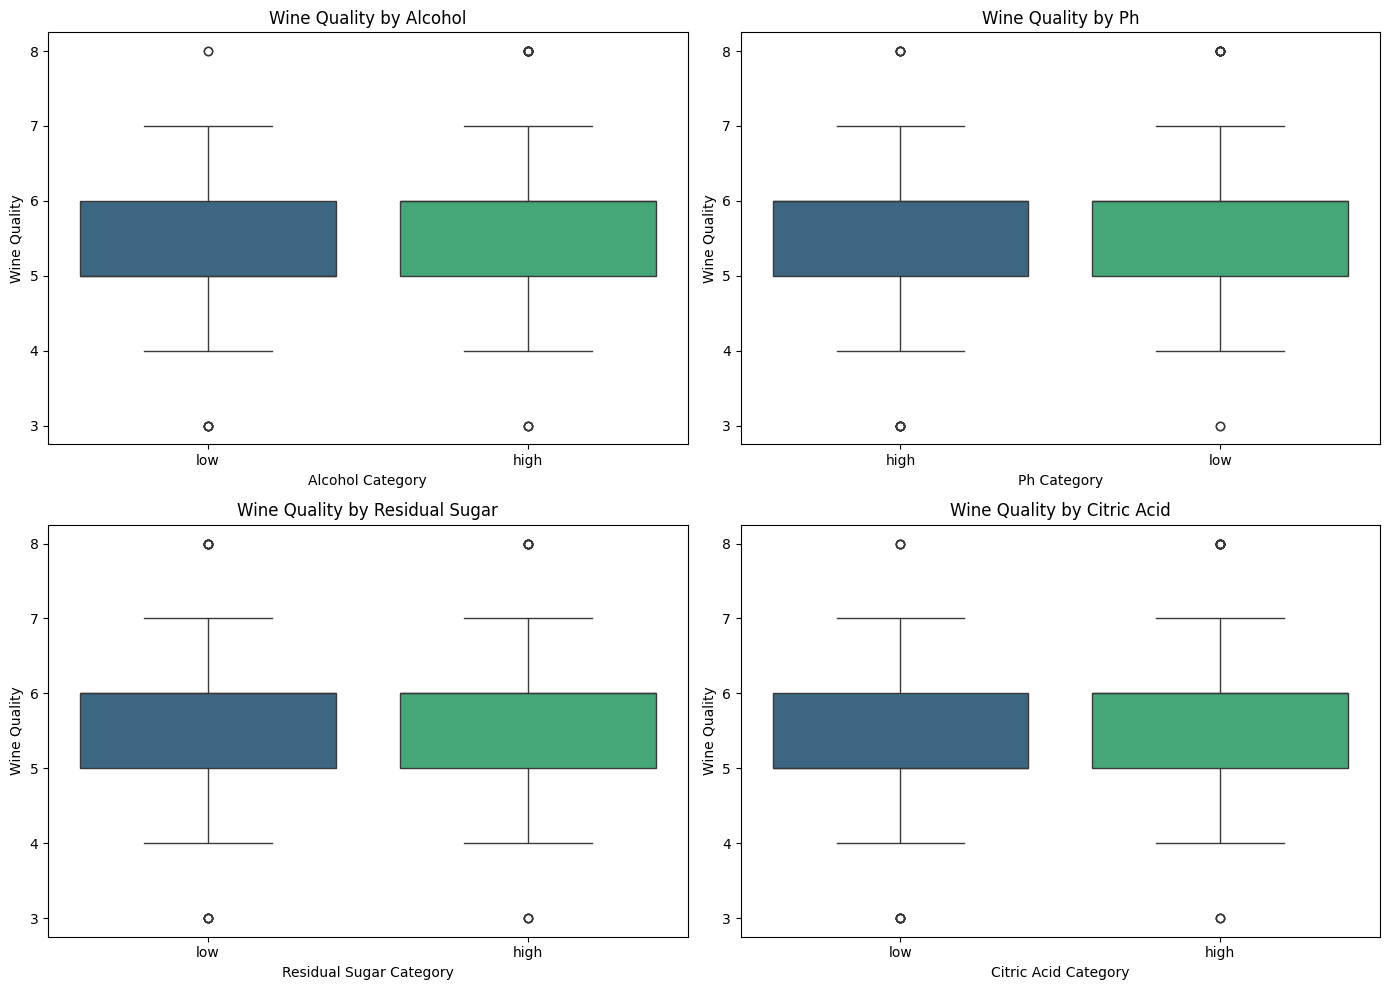

In [38]:
# The features that were categorized into 'high' and 'low'
features_to_plot = ['alcohol', 'pH', 'residual_sugar', 'citric_acid']

# Create subplots for better visualization
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, feature in enumerate(features_to_plot):
    if feature in df.columns:
        sns.boxplot(x=feature, y='quality', data=df, ax=axes[i], hue=feature, palette='viridis', legend=False)
        axes[i].set_title(f'Wine Quality by {feature.replace("_", " ").title()}')
        axes[i].set_xlabel(f'{feature.replace("_", " ").title()} Category')
        axes[i].set_ylabel('Wine Quality')
    else:
        axes[i].set_visible(False) # Hide the subplot if the column doesn't exist
        print(f"Warning: Column '{feature}' not found in DataFrame. Skipping plot.")

plt.tight_layout()
plt.show()

berdasarkan box plot di atas, terdapat beberapa kesimpulan, yaitu :


*   **Alkohol**: Anggur dengan kadar alkohol 'high' cenderung memiliki skor kualitas median yang sedikit lebih tinggi dibandingkan dengan anggur beralkohol 'low'.
*   **pH:** Anggur dengan nilai pH 'low' (yang umumnya berarti lebih asam) tampaknya memiliki skor kualitas median yang sedikit lebih tinggi daripada anggur dengan nilai pH 'high'.
*   **Gula Sisa (Residual Sugar):** Tidak ada perbedaan signifikan dalam kualitas median antara anggur dengan gula sisa 'high' dan 'low', meskipun gula sisa 'high' menunjukkan distribusi skor kualitas yang sedikit lebih luas.
*   **Asam Sitrat (Citric Acid):** Mirip dengan gula sisa, perbedaan kualitas median antara anggur asam sitrat 'high' dan 'low' tidak terlalu mencolok, tetapi asam sitrat 'high' mungkin diasosiasikan dengan kualitas yang sedikit lebih baik secara rata-rata.
